#  **Telco Customer Churn Analysis and Prediction**

## 1. Objective

The objective of this project is to analyze customer churn in a telecommunications company and build machine learning models to predict customers who are likely to leave the service. The project also aims to identify the key factors influencing churn and provide business recommendations to improve customer retention.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## 2. Data Loading

In [ ]:
df = pd.read_csv("Telco_Customer_Churn_Dataset(3).csv")


## 3. Data Exploration

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4. Data Preprocessing

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df = df.replace({'Yes':1, 'No':0}).infer_objects(copy=False)

df['gender'] = df['gender'].map({'Male':1, 'Female':0})
df = pd.get_dummies(df, drop_first=True)


/tmp/ipykernel_859/3118795818.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes':1, 'No':0}).infer_objects(copy=False)


## 5. Exploratory Data Analysis (EDA)

### Churn Distribution

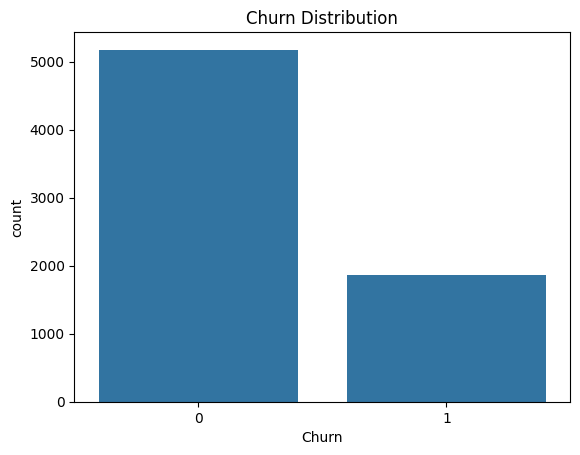

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


**Insight**:

The dataset shows that the number of non-churn customers is significantly higher than churn customers, indicating a class imbalance problem. This imbalance can affect model performance, especially in predicting churn cases, and justifies the use of techniques like class weighting.

### Monthly Charges vs Churn

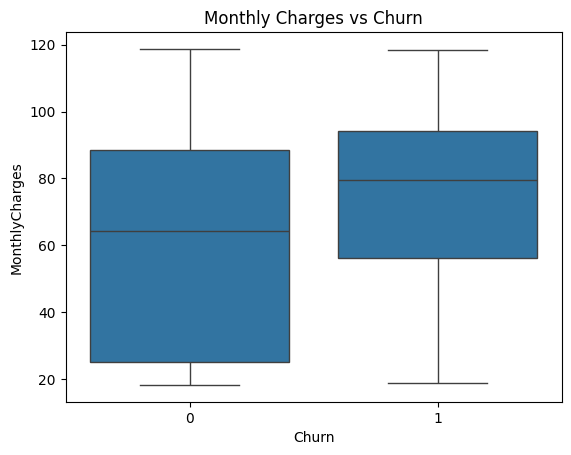

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:**

Customers who churn tend to have higher monthly charges compared to those who stay. This suggests that pricing plays a significant role in customer retention, and higher costs may lead to dissatisfaction and increased churn.

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
...,...
Contract_One year,0
Contract_Two year,0
PaymentMethod_Credit card (automatic),0
PaymentMethod_Electronic check,0


In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
X_train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
...,...
Contract_One year,0
Contract_Two year,0
PaymentMethod_Credit card (automatic),0
PaymentMethod_Electronic check,0


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Model Building

### Logistic Regression

In [ ]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7885024840312278
              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1035
           1       0.65      0.43      0.52       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.69      1409
weighted avg       0.77      0.79      0.77      1409



**Insight:**

Logistic Regression achieved an accuracy of around 78%, showing reasonable performance. However, the recall for churn cases is relatively low, indicating that the model may miss some customers who are likely to churn.

### Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8005677785663591
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



**Insight:**

The Random Forest model achieved a higher accuracy of approximately 80%, outperforming Logistic Regression. It also provides better balance between precision and recall, making it more suitable for churn prediction in this dataset.

## 7. Hyperparameter Tuning

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best Model Accuracy: 0.7423704755145494
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



**Insight:**

After hyperparameter tuning, the model performance slightly decreased, indicating that the base model was already well-optimized. This suggests that further tuning or alternative approaches may be needed for improvement.

## 8. Model Evaluation

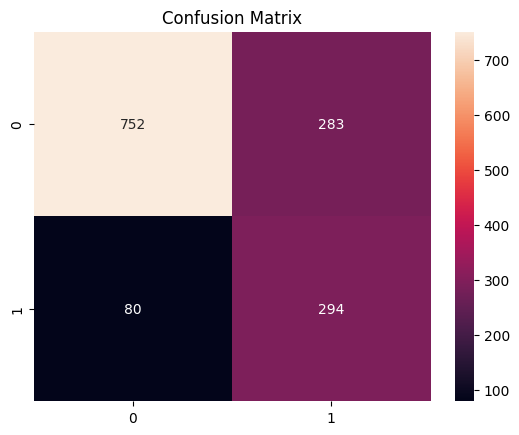

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

**Insight:**

The confusion matrix shows that the model correctly predicts a large number of non-churn customers. However, it also misclassifies a significant number of churn customers as non-churn, indicating that the model struggles to identify all churn cases. This suggests the need to improve recall for churn prediction.

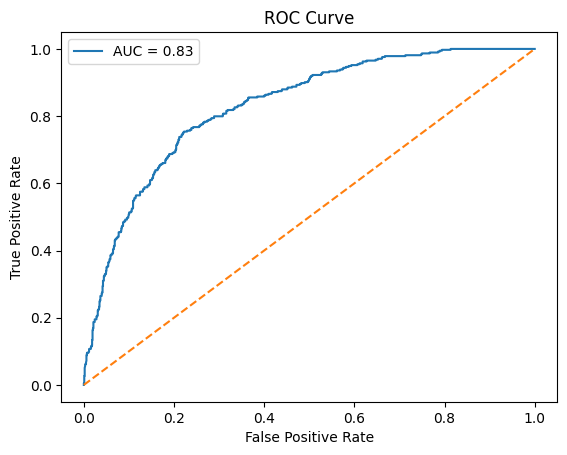

In [ ]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = %.2f" % auc_score)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Insight:**

The ROC curve shows strong model performance with an AUC score of 0.83, indicating that the model has a good ability to distinguish between churn and non-churn customers. This suggests that the model is effective for classification tasks.

## 9. Feature Importance

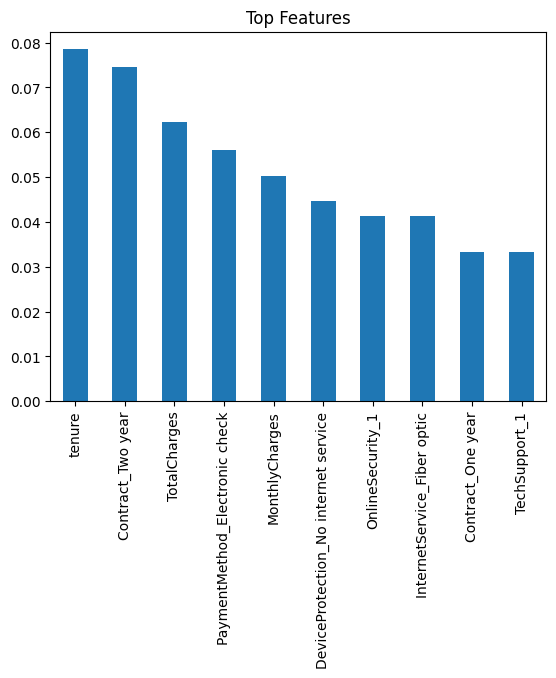

In [ ]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

**Insight:**

Feature importance analysis reveals that tenure, contract type, and total charges are the most significant factors influencing customer churn. Customers with shorter tenure and less stable contracts are more likely to churn, highlighting key areas for targeted retention strategies.

# **10. Business Recommendations**

Based on the analysis and predictive modeling of customer churn, several important factors influencing churn were identified. The Random Forest model achieved an accuracy of approximately 80%, with an AUC score of 0.83, indicating good predictive performance.

**1. Focus on Low Tenure Customers**

Feature importance analysis shows that tenure is the most influential factor affecting churn. Customers with shorter tenure are more likely to leave.
The company should implement onboarding programs, welcome offers, and early engagement strategies to retain new customers.

**2. Promote Long-Term Contracts**

Customers with month-to-month contracts show a higher churn rate compared to long-term contracts.
The company should encourage customers to switch to yearly or two-year plans by offering discounts, loyalty rewards, or bundled services.

**3. Optimize Pricing Strategy**

Customers with higher monthly and total charges are more likely to churn.
The company can introduce flexible pricing, personalized discounts, or better service packages to improve customer satisfaction.

**4. Improve Payment Experience**

Payment methods also influence churn behavior.
The company should promote convenient and automated payment options to reduce friction and improve retention.

**5. Target High-Risk Customers Using Model**

The predictive model can identify customers likely to churn. However, the model shows relatively lower recall for churn cases, meaning some at-risk customers may not be detected.
To address this, the company should:

* Use the model for early detection
* Combine it with proactive customer support and marketing campaigns

**6. Estimated Business Impact**

By focusing on key factors such as tenure, contract type, and pricing, the company can reduce churn rates significantly. Even a 5–10% reduction in churn can lead to increased customer lifetime value and improved overall revenue.


# **11.conclusion**

In this project, customer churn was analyzed using exploratory data analysis and machine learning techniques. Key factors influencing churn were identified, including tenure, contract type, and monthly charges.

Among the models tested, the Random Forest model performed best, achieving around 80% accuracy, while the tuned model improved the recall for churn prediction. This highlights the importance of balancing accuracy and recall when dealing with imbalanced datasets.

The analysis showed that customers with shorter tenure, higher charges, and flexible contract types are more likely to churn. Based on these insights, targeted retention strategies can be implemented to reduce churn.

Overall, this project demonstrates how data-driven approaches can help businesses identify at-risk customers and take proactive measures to improve customer retention and increase revenue.